In [1]:
#1. Data overview
import pandas as pd

# Para ver todas las columnas
pd.set_option('display.max_columns', None)

# Para ver todas las filas
#pd.set_option('display.max_rows', None)

#1.1 Cargar el dataset
df = pd.read_excel("Telco_Churn_EDA.xlsx")

#1.2 Dimensión del dataset
df.shape

(7043, 21)

In [2]:
#7.1 Se añaden nuevas variables
# 1. Cliente nuevo (muy importante)
df["is_new_customer"] = (df["Tenure Months"] < 6).astype(int)

# 2. Ratio gasto
df["charges_per_month"] = df["Total Charges"] / (df["Tenure Months"] + 1)

# 3. High spender
df["high_charges"] = (df["Monthly Charges"] > 80).astype(int)

# 4. Fibra sin soporte (MUY potente)
df["fiber_no_support"] = (
    (df["Internet Service"] == "Fiber optic") &
    (df["Tech Support"] == "No")
).astype(int)

# 5. Cliente mensual
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)


In [3]:
#Ver como queda el dataset
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV,is_new_customer,charges_per_month,high_charges,fiber_no_support,is_month_to_month
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239,1,36.050000,0,0,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701,1,50.550000,0,1,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372,0,91.166667,1,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003,0,105.036207,1,0,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340,0,100.726000,1,1,1


In [4]:
df.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV,is_new_customer,charges_per_month,high_charges,fiber_no_support,is_month_to_month
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,4400.295755,0.194661,58.990789,0.378532,0.316626,0.550192
std,24.559481,30.090047,2266.794470,0.441561,1183.057152,0.395968,30.579745,0.485056,0.465193,0.497510
min,0.000000,18.250000,0.000000,0.000000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,3469.000000,0.000000,26.041493,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,4527.000000,0.000000,60.937879,0.000000,0.000000,1.000000
75%,55.000000,89.850000,3786.600000,1.000000,5380.500000,0.000000,84.830742,1.000000,1.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,6500.000000,1.000000,118.969863,1.000000,1.000000,1.000000


In [5]:
#7.2 Definir x e y
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [6]:
#7.3 Train/Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
#7.4 Identificar columnas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["str"]).columns

In [8]:
#7.5 Preprocesador
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

In [9]:
#7.6 Pipeline con SMOTE + XGBoost
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline_xgb_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [10]:
#7.7 Entrenar
pipeline_xgb_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [11]:
#7.8 Predicciones
y_pred_xgb_smote = pipeline_xgb_smote.predict(X_test)
y_prob_xgb_smote = pipeline_xgb_smote.predict_proba(X_test)[:,1]

In [12]:
#7.9 Evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))

[[879 156]
 [142 232]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1035
           1       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8487496447854503


In [76]:
#7.10 Threshold tuning
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb_smote >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append([t, recall, precision, f1])

import pandas as pd
results_df = pd.DataFrame(results, columns=["threshold","recall","precision","f1"])
print(results_df)

    threshold    recall  precision        f1
0        0.10  0.943850   0.432069  0.592779
1        0.15  0.906417   0.455645  0.606440
2        0.20  0.858289   0.488584  0.622696
3        0.25  0.823529   0.505747  0.626653
4        0.30  0.794118   0.528470  0.634615
5        0.35  0.764706   0.551060  0.640538
6        0.40  0.716578   0.561845  0.629847
7        0.45  0.655080   0.564516  0.606436
8        0.50  0.620321   0.597938  0.608924
9        0.55  0.566845   0.644377  0.603129
10       0.60  0.502674   0.673835  0.575804
11       0.65  0.430481   0.679325  0.527005
12       0.70  0.371658   0.720207  0.490300
13       0.75  0.310160   0.729560  0.435272
14       0.80  0.229947   0.754386  0.352459
15       0.85  0.144385   0.782609  0.243792


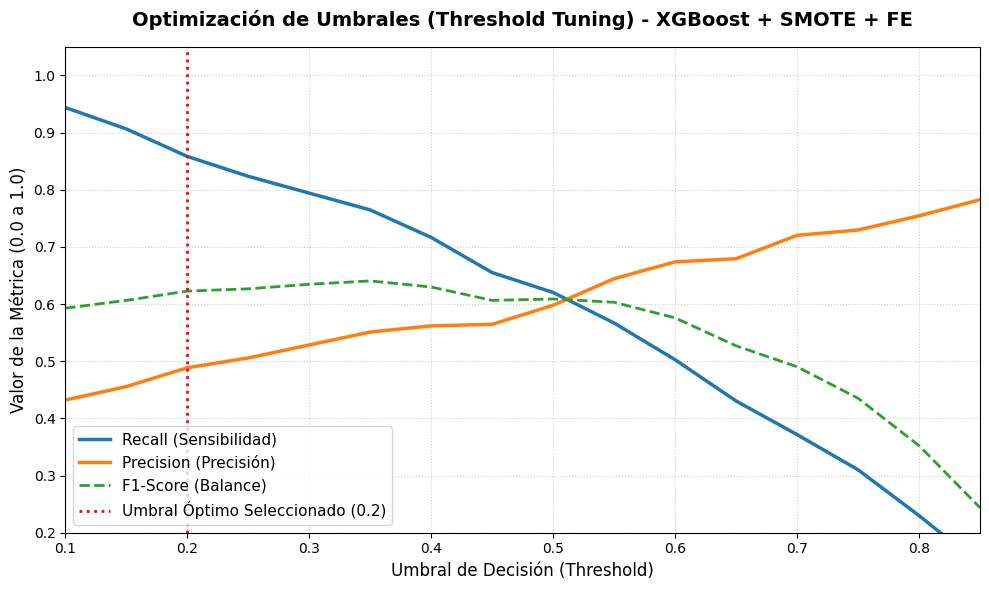

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()

#Generar gráfica umbral

# Gráfica 3: XGBoost (Punto óptimo: 0.20)
graficar_threshold_tuning(y_test, y_prob_xgb_smote, "XGBoost + SMOTE + FE", umbral_optimo=0.20)

In [26]:
#8.1 Pipeline Logistic + SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pipeline_log_smote_fe = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [27]:
#8.3 Entrenar
pipeline_log_smote_fe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [28]:
#8.4 Evaluar
y_pred_log_fe = pipeline_log_smote_fe.predict(X_test)
y_prob_log_fe = pipeline_log_smote_fe.predict_proba(X_test)[:,1]

In [29]:
#Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(confusion_matrix(y_test, y_pred_log_fe))

print(classification_report(y_test, y_pred_log_fe))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log_fe))

[[768 267]
 [ 83 291]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8506109690252913


In [30]:
#8.6 Threshold tuning
from sklearn.metrics import confusion_matrix, classification_report

# aplicar threshold
y_pred_t = (y_prob_log_fe >= 0.4).astype(int)

# evaluar
print(confusion_matrix(y_test, y_pred_t))
print(classification_report(y_test, y_pred_t))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log_fe))

[[689 346]
 [ 58 316]]
              precision    recall  f1-score   support

           0       0.92      0.67      0.77      1035
           1       0.48      0.84      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.80      0.71      0.73      1409

ROC-AUC: 0.8506109690252913


In [31]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob_log_fe >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append([t, recall, precision, f1])

import pandas as pd
results_df = pd.DataFrame(results, columns=["threshold","recall","precision","f1"])
print(results_df)

    threshold    recall  precision        f1
0        0.10  0.986631   0.357212  0.524520
1        0.15  0.975936   0.385835  0.553030
2        0.20  0.957219   0.405896  0.570064
3        0.25  0.935829   0.429448  0.588730
4        0.30  0.906417   0.445466  0.597357
5        0.35  0.879679   0.460784  0.604779
6        0.40  0.844920   0.477341  0.610039
7        0.45  0.823529   0.502447  0.624113
8        0.50  0.778075   0.521505  0.624464
9        0.55  0.751337   0.536260  0.625835
10       0.60  0.721925   0.564854  0.633803
11       0.65  0.671123   0.590588  0.628285
12       0.70  0.609626   0.624658  0.617050
13       0.75  0.534759   0.653595  0.588235
14       0.80  0.425134   0.722727  0.535354
15       0.85  0.286096   0.764286  0.416342


In [78]:
# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [79]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [80]:
#predicciones
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

In [81]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

[[892 143]
 [151 223]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8424655764809217


In [82]:
#Probar distintos threshold
import numpy as np
import pandas as pd

from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    y_pred_t = (y_prob_rf_smote >= t).astype(int)

    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, recall, precision, f1])

results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

print(results_rf_smote)

    threshold    recall  precision        f1
0        0.10  0.957219   0.383298  0.547401
1        0.15  0.922460   0.421760  0.578859
2        0.20  0.906417   0.458108  0.608618
3        0.25  0.863636   0.485714  0.621752
4        0.30  0.812834   0.513514  0.629400
5        0.35  0.775401   0.543071  0.638767
6        0.40  0.729947   0.566390  0.637850
7        0.45  0.657754   0.585714  0.619647
8        0.50  0.596257   0.609290  0.602703
9        0.55  0.548128   0.636646  0.589080
10       0.60  0.489305   0.655914  0.560490
11       0.65  0.430481   0.665289  0.522727
12       0.70  0.339572   0.686486  0.454383
13       0.75  0.291444   0.703226  0.412098
14       0.80  0.235294   0.715447  0.354125
15       0.85  0.171123   0.771084  0.280088


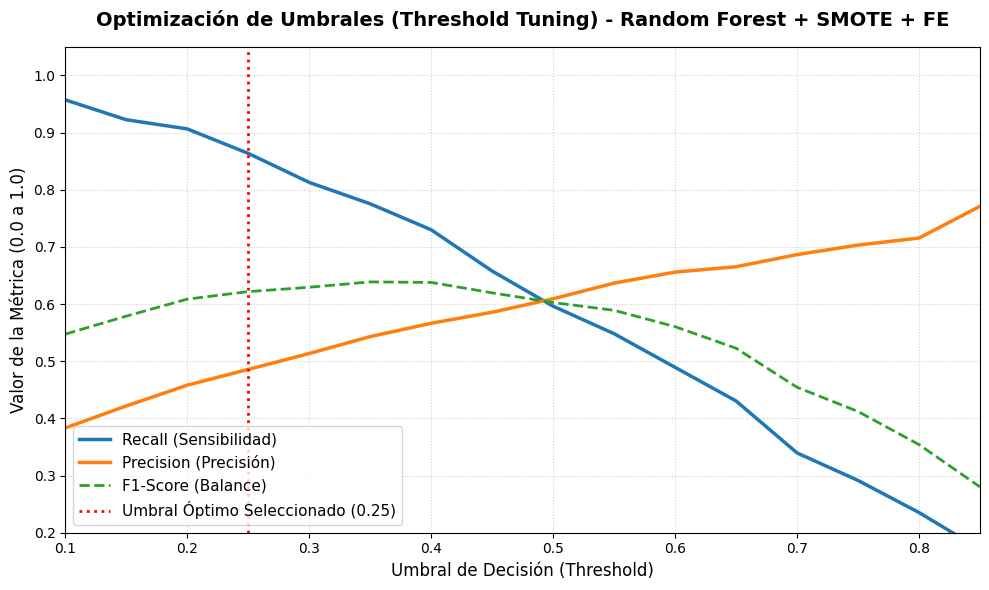

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()


graficar_threshold_tuning(y_test, y_prob_rf_smote, "Random Forest + SMOTE + FE", umbral_optimo=0.25)


In [71]:
# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [72]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [68]:
#predicciones
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

In [69]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

[[892 143]
 [151 223]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8424655764809217


In [70]:
#Probar distintos threshold
import numpy as np
import pandas as pd

from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    y_pred_t = (y_prob_rf_smote >= t).astype(int)

    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, recall, precision, f1])

results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

print(results_rf_smote)

    threshold    recall  precision        f1
0        0.10  0.957219   0.383298  0.547401
1        0.15  0.922460   0.421760  0.578859
2        0.20  0.906417   0.458108  0.608618
3        0.25  0.863636   0.485714  0.621752
4        0.30  0.812834   0.513514  0.629400
5        0.35  0.775401   0.543071  0.638767
6        0.40  0.729947   0.566390  0.637850
7        0.45  0.657754   0.585714  0.619647
8        0.50  0.596257   0.609290  0.602703
9        0.55  0.548128   0.636646  0.589080
10       0.60  0.489305   0.655914  0.560490
11       0.65  0.430481   0.665289  0.522727
12       0.70  0.339572   0.686486  0.454383
13       0.75  0.291444   0.703226  0.412098
14       0.80  0.235294   0.715447  0.354125
15       0.85  0.171123   0.771084  0.280088


In [23]:
#2.1 Crear modelo Random Forest
from sklearn.ensemble import RandomForestClassifier
#2.2 Pipeline con Random Forest
pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [24]:
#2.3 Entrenar modelo
pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

In [25]:
#2.4 Predicciones
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [26]:
#2.5 Evaluacion
#2.5.1 Matriz de Confusión
print(confusion_matrix(y_test, y_pred_rf))
#2.5.2 Reporte de Clasificación
print(classification_report(y_test, y_pred_rf))
#2.5.3 ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[918 117]
 [182 192]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8393396884445478


In [27]:
#2.6 Feature Importance
model = pipeline_rf.named_steps["model"]
importances = model.feature_importances_

In [28]:
#Obtener nombres de variables
feature_names = pipeline_rf.named_steps["preprocessing"].get_feature_names_out()

In [29]:
#Ver top variables
feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values(ascending=False).head(10)

num__Total Charges                      0.118948
num__Tenure Months                      0.115656
num__Monthly Charges                    0.109148
num__charges_per_month                  0.108913
num__CLTV                               0.105982
num__is_month_to_month                  0.054200
num__fiber_no_support                   0.035335
cat__Dependents_Yes                     0.030400
cat__Payment Method_Electronic check    0.027932
cat__Gender_Male                        0.020188
dtype: float64

In [74]:
#Distintos threshold

# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])



In [75]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [78]:
#predicciones
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

y_pred_rf_smote = (y_prob_rf_smote >= 0.25).astype(int)

In [81]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote)) 

[[681 354]
 [ 45 329]]
              precision    recall  f1-score   support

           0       0.94      0.66      0.77      1035
           1       0.48      0.88      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.72      0.73      1409

ROC-AUC: 0.8424655764809217


In [ ]:

# Probar distintos threshold 
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_rf_smote >= t_round).astype(int)

    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print(results_rf_smote)

    threshold    recall  precision        f1
0        0.10  0.957219   0.383298  0.547401
1        0.15  0.925134   0.415366  0.573322
2        0.20  0.906417   0.449007  0.600531
3        0.25  0.879679   0.481698  0.622517
4        0.30  0.828877   0.505710  0.628166
5        0.35  0.780749   0.541744  0.639650
6        0.40  0.740642   0.560729  0.638249
7        0.45  0.668449   0.574713  0.618047
8        0.50  0.604278   0.605898  0.605087
9        0.55  0.564171   0.635542  0.597734
10       0.60  0.500000   0.658451  0.568389
11       0.65  0.438503   0.658635  0.526485
12       0.70  0.363636   0.676617  0.473043
13       0.75  0.307487   0.705521  0.428305
14       0.80  0.243316   0.705426  0.361829
15       0.85  0.192513   0.782609  0.309013


In [13]:
#7.6 Pipeline con SMOTE + XGBoost + threshold(0,20)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline_xgb_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [14]:
#7.7 Entrenar
pipeline_xgb_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [17]:
#7.8 Predicciones
y_pred_xgb_smote = pipeline_xgb_smote.predict(X_test)
y_prob_xgb_smote = pipeline_xgb_smote.predict_proba(X_test)[:,1]

y_pred_xgb_smote = (y_prob_xgb_smote >= 0.20).astype(int)

In [80]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))

[[699 336]
 [ 53 321]]
              precision    recall  f1-score   support

           0       0.93      0.68      0.78      1035
           1       0.49      0.86      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.81      0.72      0.74      1409

ROC-AUC: 0.8487496447854503


In [ ]:
#RANDOM FOREST Optimización Hiperparámetros

In [34]:
# modelo random forest con SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
# crear pipeline
pipeline_rf_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [35]:
# Entrenar
pipeline_rf_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [36]:
#predicciones
y_pred_rf_smote = pipeline_rf_smote.predict(X_test)
y_prob_rf_smote = pipeline_rf_smote.predict_proba(X_test)[:,1]

y_pred_rf_smote = (y_prob_rf_smote >= 0.25).astype(int)

In [37]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote)) 

[[681 354]
 [ 45 329]]
              precision    recall  f1-score   support

           0       0.94      0.66      0.77      1035
           1       0.48      0.88      0.62       374

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.72      0.73      1409

ROC-AUC: 0.8424655764809217


In [38]:
# 8.1 Optimización de hiperparámetros con GridSearchCV
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de valores a probar
# Usamos el prefijo 'model__' porque así llamaste al paso en el Pipeline
param_grid = {
    'model__n_estimators': [100, 200, 300],         # Número de árboles
    'model__max_depth': [None, 10, 20],             # Profundidad máxima
    'model__min_samples_split': [2, 5, 10],         # Muestras mínimas para dividir
    'model__class_weight': ['balanced', None]       # Prueba con y sin balanceo interno
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_rf_smote,
    param_grid=param_grid,
    scoring='roc_auc',      # Optimizamos basándonos en el área bajo la curva
    cv=5,                   # Validación cruzada de 5 pliegues
    n_jobs=-1,              # Usa todos los procesadores disponibles
    verbose=2               # Muestra el progreso en pantalla
)

# Entrenar probando todas las combinaciones (esto tardará unos minutos)
print("Iniciando entrenamiento y optimización...")
grid_search.fit(X_train, y_train)

# Mostrar los mejores resultados encontrados
print("\n--- Resultados de GridSearchCV ---")
print(f"Mejor ROC-AUC en entrenamiento (CV): {grid_search.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Extraer el mejor modelo para usarlo en adelante
best_pipeline_rf = grid_search.best_estimator_

Iniciando entrenamiento y optimización...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- Resultados de GridSearchCV ---
Mejor ROC-AUC en entrenamiento (CV): 0.8576
Mejores hiperparámetros encontrados:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [39]:
# predicciones con el MEJOR modelo encontrado
y_pred_rf_smote = best_pipeline_rf.predict(X_test)
y_prob_rf_smote = best_pipeline_rf.predict_proba(X_test)[:,1]

# Aplicar tu threshold personalizado de 0.25
y_pred_rf_smote = (y_prob_rf_smote >= 0.3).astype(int)

In [40]:
#Evaluación
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote)) 

[[671 364]
 [ 40 334]]
              precision    recall  f1-score   support

           0       0.94      0.65      0.77      1035
           1       0.48      0.89      0.62       374

    accuracy                           0.71      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.71      0.73      1409

ROC-AUC: 0.851596527939239


--- Tabla de Métricas por Umbral ---
 threshold   recall  precision       f1
      0.10 0.983957   0.368368 0.536052
      0.15 0.951872   0.400450 0.563737
      0.20 0.941176   0.431373 0.591597
      0.25 0.917112   0.456117 0.609236
      0.30 0.893048   0.478510 0.623134
      0.35 0.855615   0.503145 0.633663
      0.40 0.802139   0.527241 0.636267
      0.45 0.745989   0.552475 0.634812
      0.50 0.692513   0.559395 0.618877
      0.55 0.660428   0.577103 0.615960
      0.60 0.620321   0.607330 0.613757
      0.65 0.558824   0.631420 0.592908
      0.70 0.505348   0.684783 0.581538
      0.75 0.417112   0.715596 0.527027
      0.80 0.294118   0.743243 0.421456
      0.85 0.197861   0.778947 0.315565


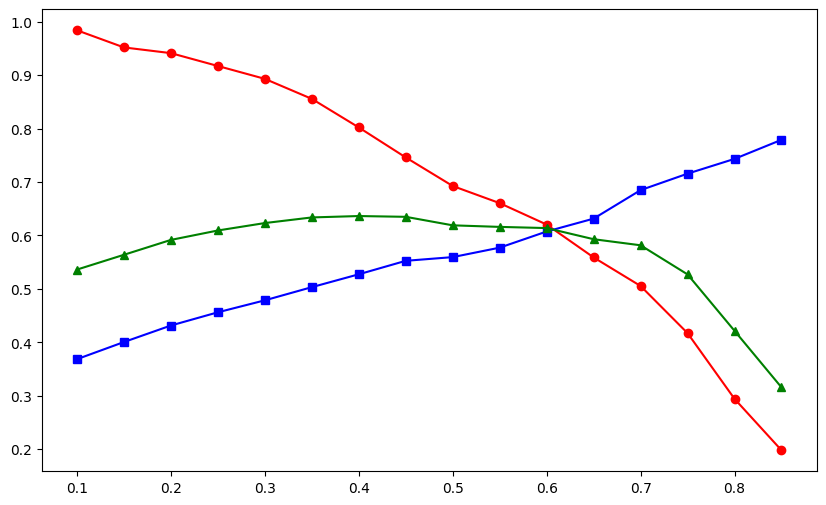

In [ ]:

# Probar distintos thresholds y graficar resultados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Obtenemos las probabilidades del mejor modelo encontrado en el GridSearch
# (Si ya tienes 'y_prob_rf_smote' de la celda anterior, no pasa nada por sobreescribirlo)
y_prob_rf_smote = best_pipeline_rf.predict_proba(X_test)[:, 1]

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_rf_smote >= t_round).astype(int)

    # Calculamos métricas (añadido zero_division=0 para evitar warnings de sklearn)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

# DataFrame con los resultados
results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print("--- Tabla de Métricas por Umbral ---")
print(results_rf_smote.to_string(index=False))

# =====================================================================
# EXTRA PARA EL TFG: Gráfico de Evolución de Métricas
# =====================================================================
plt.figure(figsize=(10, 6))

# Dibujamos las tres líneas
plt.plot(results_rf_smote['threshold'], results_rf_smote['recall'], marker='o', label='Recall (Fugas capturadas)', color='red')
plt.plot(results_rf_smote['threshold'], results_rf_smote['precision'], marker='s', label='Precision (Acierto en lo que predecimos)', color='blue')
plt.plot(results_rf_smote['threshold'], results_rf_smote['f1'], marker='^', label='F1-Score (Equilibrio)', color='green')



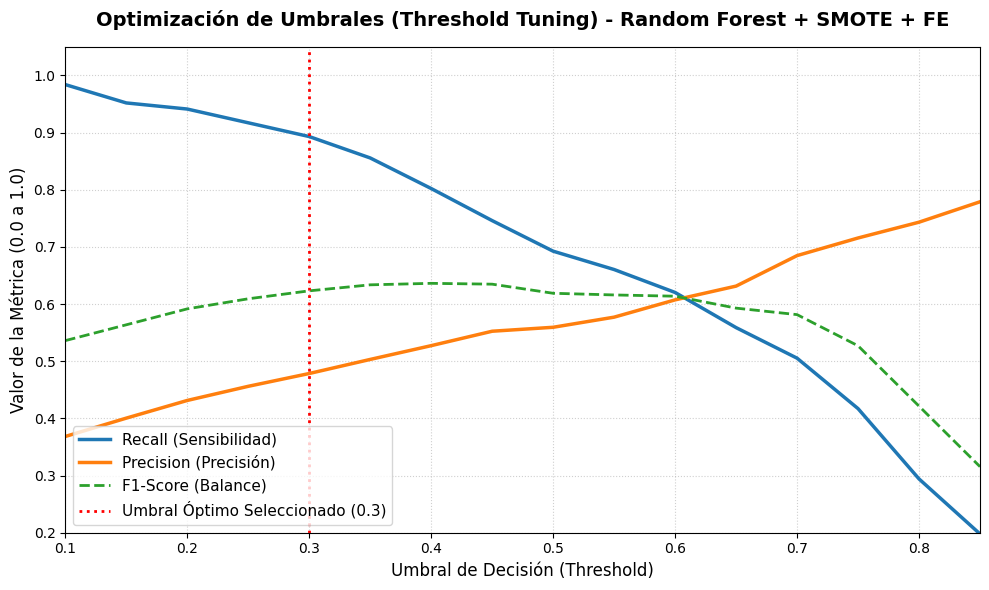

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()




# Gráfica: Random Forest (Punto óptimo: 0.30)
graficar_threshold_tuning(y_test, y_prob_rf_smote, "Random Forest + SMOTE + FE", umbral_optimo=0.3)


In [ ]:
#XGBoost Optimización Hiperparámetros

In [9]:
#7.6 Pipeline con SMOTE + XGBoost
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline_xgb_smote = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ))
])

In [10]:
#7.7 Entrenar
pipeline_xgb_smote.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. Th

In [11]:
# 8.2 Optimización de hiperparámetros para XGBoost
from sklearn.model_selection import GridSearchCV

# Definir la cuadrícula de valores a probar
# OJO: Mantenemos el prefijo 'model__' porque así llamaste al paso en tu Pipeline
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],         # Número de árboles
    'model__learning_rate': [0.01, 0.05, 0.1],      # Tasa de aprendizaje
    'model__max_depth': [3, 4, 5],                  # Profundidad de cada árbol
    'model__subsample': [0.8, 1.0],                 # % de filas usadas por árbol
    'model__colsample_bytree': [0.8, 1.0]           # % de columnas usadas por árbol
}

# Configurar GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb_smote,
    param_grid=param_grid_xgb,
    scoring='roc_auc',      # Seguimos usando ROC-AUC por el desbalanceo
    cv=5,                   # Validación cruzada de 5 pliegues
    n_jobs=-1,              # Usa todos los núcleos de Colab
    verbose=2               # Para ir viendo el progreso (XGBoost suele tardar más)
)

# Entrenar probando todas las combinaciones
print("Iniciando entrenamiento y optimización de XGBoost...")
grid_search_xgb.fit(X_train, y_train)

# Mostrar los mejores resultados encontrados
print("\n--- Resultados de GridSearchCV para XGBoost ---")
print(f"Mejor ROC-AUC en entrenamiento (CV): {grid_search_xgb.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
print(grid_search_xgb.best_params_)

# Extraer el mejor modelo para usarlo en adelante
best_pipeline_xgb = grid_search_xgb.best_estimator_

Iniciando entrenamiento y optimización de XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

--- Resultados de GridSearchCV para XGBoost ---
Mejor ROC-AUC en entrenamiento (CV): 0.8613
Mejores hiperparámetros encontrados:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [12]:
#7.8 Predicciones
y_pred_xgb_smote = best_pipeline_xgb.predict(X_test)
# Sacamos las probabilidades del modelo XGBoost optimizado
y_prob_xgb_smote = best_pipeline_xgb.predict_proba(X_test)[:, 1]

y_pred_t = (y_prob_xgb_smote >= 0.25).astype(int)


In [13]:
#7.9 Evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_t))
print(classification_report(y_test, y_pred_t))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_t))

[[670 365]
 [ 47 327]]
              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1035
           1       0.47      0.87      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409

ROC-AUC: 0.7608372729856107


--- Tabla de Métricas por Umbral ---
 threshold   recall  precision       f1
      0.10 0.970588   0.406951 0.573460
      0.15 0.941176   0.438903 0.598639
      0.20 0.914439   0.462788 0.614555
      0.25 0.874332   0.472543 0.613508
      0.30 0.842246   0.504000 0.630631
      0.35 0.791444   0.519298 0.627119
      0.40 0.748663   0.529301 0.620155
      0.45 0.716578   0.560669 0.629108
      0.50 0.671123   0.585082 0.625156
      0.55 0.620321   0.597938 0.608924
      0.60 0.566845   0.638554 0.600567
      0.65 0.518717   0.687943 0.591463
      0.70 0.427807   0.720721 0.536913
      0.75 0.320856   0.745342 0.448598
      0.80 0.235294   0.765217 0.359918
      0.85 0.139037   0.812500 0.237443


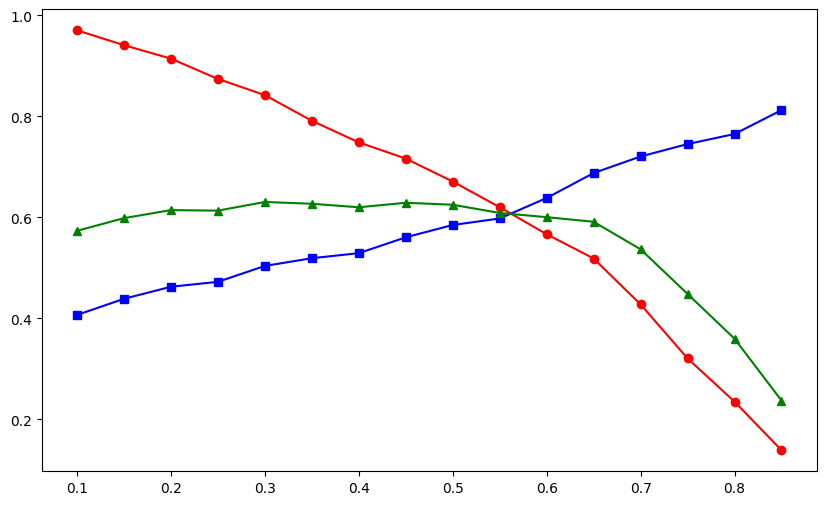

In [14]:

# Probar distintos thresholds y graficar resultados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Obtenemos las probabilidades del mejor modelo encontrado en el GridSearch
# (Si ya tienes 'y_prob_rf_smote' de la celda anterior, no pasa nada por sobreescribirlo)
y_prob_xgb_smote = best_pipeline_xgb.predict_proba(X_test)[:, 1]

# Generamos los umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    # CLAVE: Redondeamos 't' a 2 decimales para evitar el ruido de np.arange
    t_round = round(t, 2)
    
    # Usamos el umbral redondeado limpiamente
    y_pred_t = (y_prob_xgb_smote >= t_round).astype(int)

    # Calculamos métricas (añadido zero_division=0 para evitar warnings de sklearn)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t)

    # Guardamos t_round para que la tabla quede bonita con 2 decimales
    results.append([t_round, recall, precision, f1])

# DataFrame con los resultados
results_rf_smote = pd.DataFrame(
    results,
    columns=["threshold", "recall", "precision", "f1"]
)

# Mostramos la tabla limpia
print("--- Tabla de Métricas por Umbral ---")
print(results_rf_smote.to_string(index=False))
plt.figure(figsize=(10, 6))

# Dibujamos las tres líneas
plt.plot(results_rf_smote['threshold'], results_rf_smote['recall'], marker='o', label='Recall (Fugas capturadas)', color='red')
plt.plot(results_rf_smote['threshold'], results_rf_smote['precision'], marker='s', label='Precision (Acierto en lo que predecimos)', color='blue')
plt.plot(results_rf_smote['threshold'], results_rf_smote['f1'], marker='^', label='F1-Score (Equilibrio)', color='green')



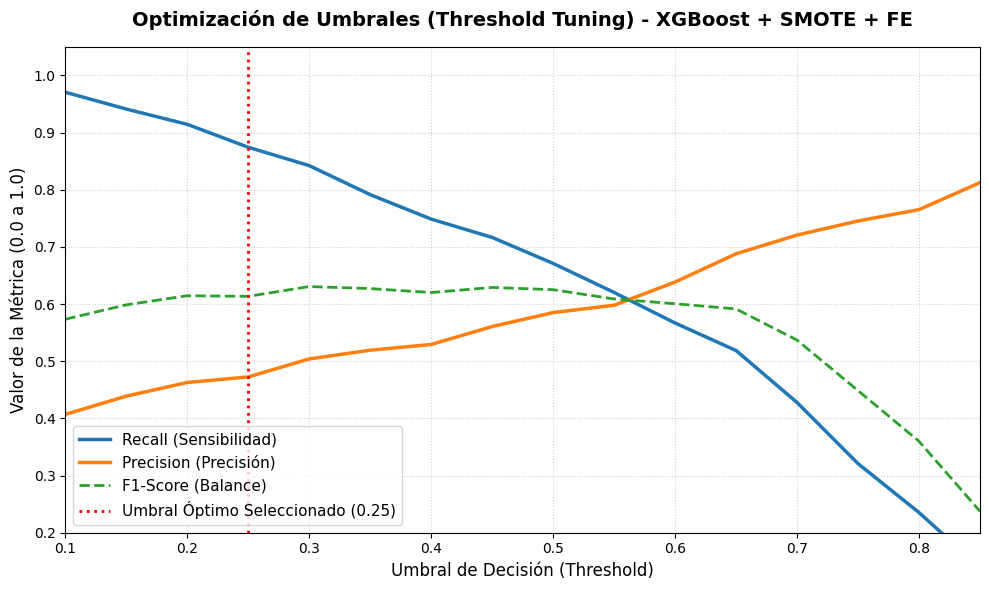

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# 1. Definimos los umbrales a evaluar
thresholds = np.arange(0.1, 0.9, 0.05)

# 2. Función auxiliar para calcular métricas y graficar
def graficar_threshold_tuning(y_true, y_probs, nombre_modelo, umbral_optimo):
    results = []
    
    # Calcular métricas para cada umbral
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        recall = recall_score(y_true, y_pred_t)
        precision = precision_score(y_true, y_pred_t)
        f1 = f1_score(y_true, y_pred_t)
        results.append([t, recall, precision, f1])
    
    # Convertir a DataFrame para facilitar el manejo
    df_metrics = pd.DataFrame(results, columns=["threshold", "Recall", "Precision", "F1-Score"])
    
    # Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(df_metrics["threshold"], df_metrics["Recall"], label="Recall (Sensibilidad)", color="#1f77b4", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["Precision"], label="Precision (Precisión)", color="#ff7f0e", linewidth=2.5)
    plt.plot(df_metrics["threshold"], df_metrics["F1-Score"], label="F1-Score (Balance)", color="#2ca02c", linestyle="--", linewidth=2)
    
    # Línea vertical en el umbral seleccionado por negocio
    plt.axvline(x=umbral_optimo, color="red", linestyle=":", linewidth=2, 
                label=f"Umbral Óptimo Seleccionado ({umbral_optimo})")
    
    # Estética de la gráfica para el TFG
    plt.title(f"Optimización de Umbrales (Threshold Tuning) - {nombre_modelo}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Umbral de Decisión (Threshold)", fontsize=12)
    plt.ylabel("Valor de la Métrica (0.0 a 1.0)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.xlim(0.1, 0.85)
    plt.ylim(0.2, 1.05)
    plt.legend(loc="lower left", fontsize=11)
    plt.tight_layout()
    plt.show()



# Gráfica 3: XGBoost (Punto óptimo: 0.25)
graficar_threshold_tuning(y_test, y_prob_xgb_smote, "XGBoost + SMOTE + FE", umbral_optimo=0.25) 